<a href="https://colab.research.google.com/github/dilek-gokalp/dilek-gokalp/blob/main/thesis_analysis_eu_freight_emissions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
import pandas as pd
import numpy as np


file_path = "/content/AB_road_transport_CO2_per_tkm.xlsx"
freight = pd.read_excel(file_path)


freight.columns = freight.columns.str.strip()

print("Loaded:", freight.shape)
print("Columns:", list(freight.columns))
display(freight.head())


Loaded: (198, 5)
Columns: ['Country', 'Year', 'TonKm', 'CO2', 'CO2_per_tkm_kg']


,Country,Year,TonKm,CO2,CO2_per_tkm_kg
0,Bulgaria,2015,161567,1377240.04,8.524266
1,Czechia,2015,438907,1693810.67,3.859156
2,Germany,2015,3035329,1913753.97,0.630493
3,Estonia,2015,28162,1838197.77,65.272274
4,Ireland,2015,117090,2143578.78,18.307104


In [ ]:
import pandas as pd
import numpy as np


df = freight.copy()

df = df.dropna(subset=['CO2', 'TonKm', 'Year'])


df = df[df['Year'] <= 2022]


df['log_CO2'] = np.log(df['CO2'])
df['log_TonKm'] = np.log(df['TonKm'])

print("Final panel shape:", df.shape)
df.head()


Final panel shape: (170, 7)


,Country,Year,TonKm,CO2,CO2_per_tkm_kg,log_CO2,log_TonKm
0,Bulgaria,2015,161567,1377240.04,8.524266,14.135592,11.992675
1,Czechia,2015,438907,1693810.67,3.859156,14.342491,12.992043
2,Germany,2015,3035329,1913753.97,0.630493,14.464577,14.925830
3,Estonia,2015,28162,1838197.77,65.272274,14.424296,10.245729
4,Ireland,2015,117090,2143578.78,18.307104,14.577987,11.670698


In [ ]:
import statsmodels.api as sm

X = df[['log_TonKm']]
y = df['log_CO2']

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                log_CO2   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.309
Date:                Wed, 04 Feb 2026   Prob (F-statistic):              0.130
Time:                        20:07:37   Log-Likelihood:                 35.971
No. Observations:                 175   AIC:                            -67.94
Df Residuals:                     173   BIC:                            -61.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.5858      0.162     90.206      0.0

,Feature,Importance
0,TonKm,0.935345
1,Year,0.064655


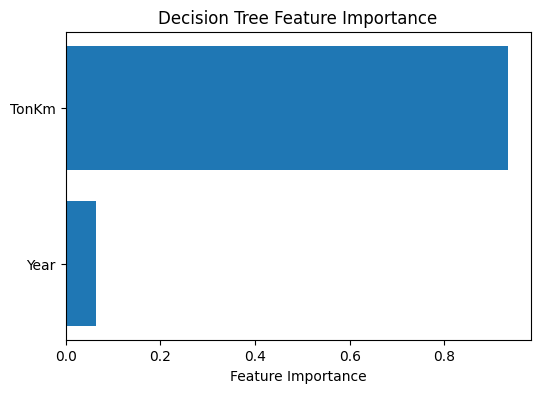

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(feature_importance)

# Plot
plt.figure(figsize=(6,4))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


X = df[['TonKm', 'Year']]
y = df['CO2']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


dt_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)


y_pred = dt_model.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, y_pred))
print("Decision Tree R²:", r2_score(y_test, y_pred))


Decision Tree MSE: 106024363383.47997
Decision Tree R²: 0.18999099582257684


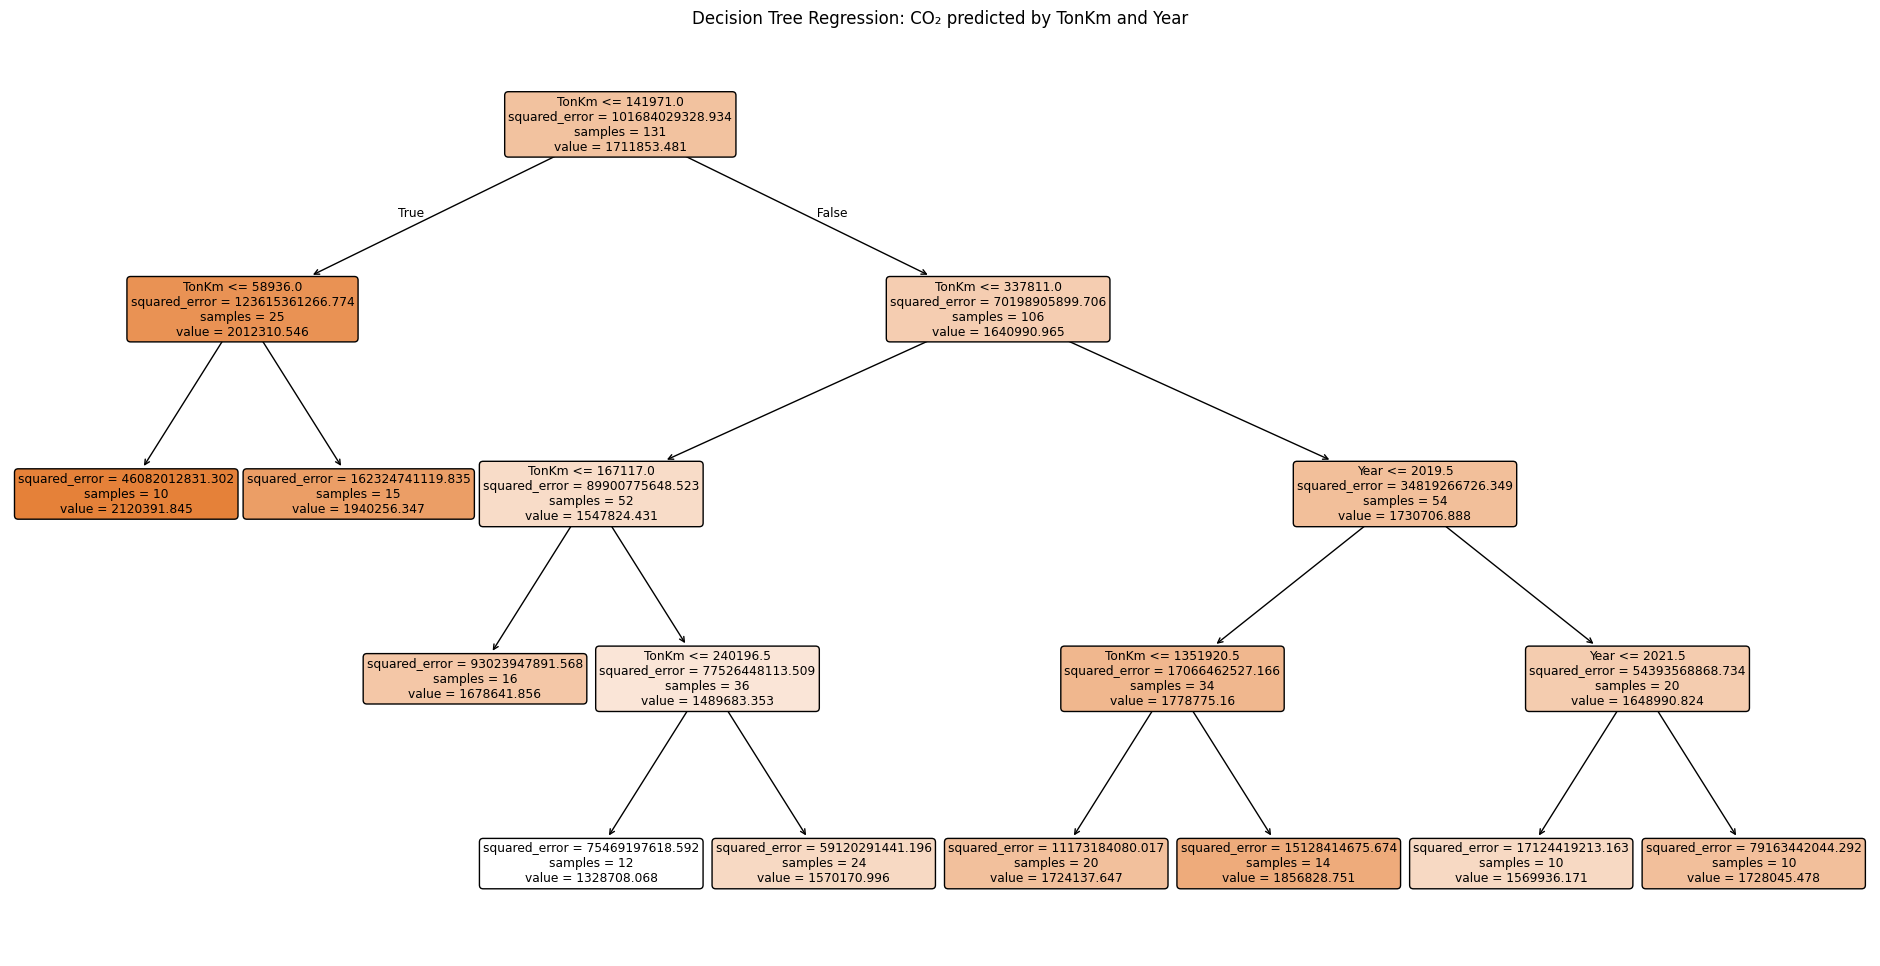

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Regression: CO₂ predicted by TonKm and Year")
plt.show()


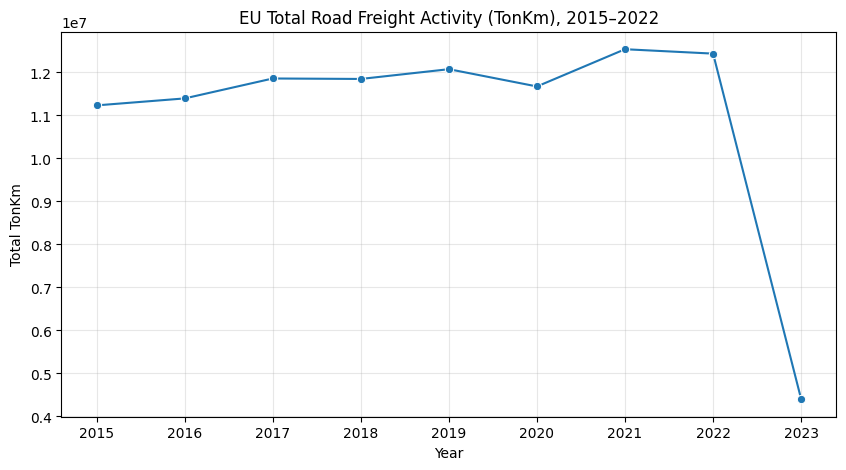

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_sum, x='Year', y='TonKm', marker='o')
plt.title('EU Total Road Freight Activity (TonKm), 2015–2022')
plt.xlabel('Year')
plt.ylabel('Total TonKm')
plt.grid(True, alpha=0.3)
plt.show()


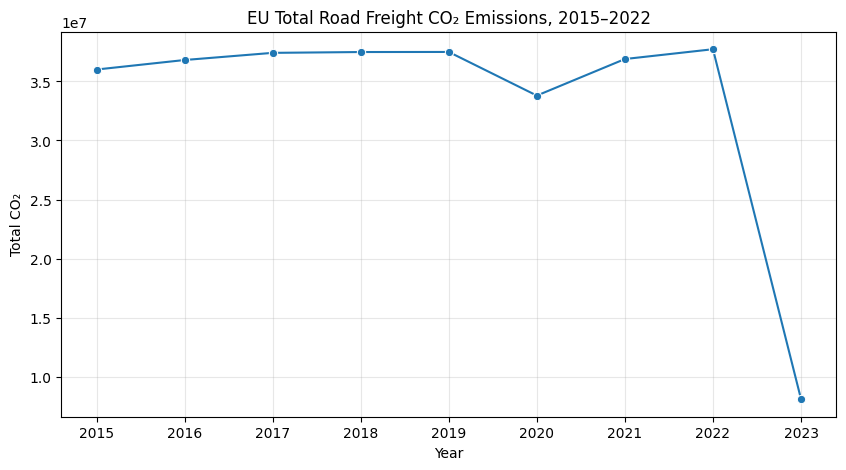

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_sum, x='Year', y='CO2', marker='o')
plt.title('EU Total Road Freight CO₂ Emissions, 2015–2022')
plt.xlabel('Year')
plt.ylabel('Total CO₂')
plt.grid(True, alpha=0.3)
plt.show()


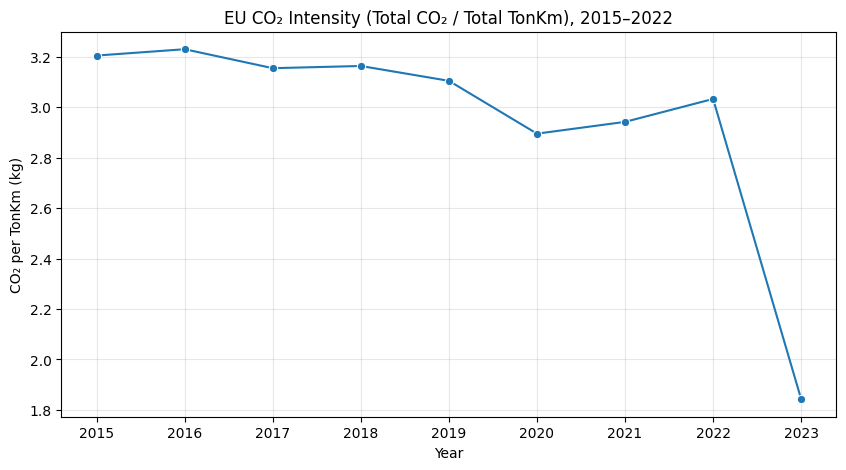

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_intensity_weighted, x='Year', y='CO2_per_tkm_kg', marker='o')
plt.title('EU CO₂ Intensity (Total CO₂ / Total TonKm), 2015–2022')
plt.xlabel('Year')
plt.ylabel('CO₂ per TonKm (kg)')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Sadece gerekli kolonları al, eksikleri at
df = freight.copy()

df = df.dropna(subset=['CO2', 'TonKm', 'Year'])

# Log dönüşümler (OLS için)
df['log_CO2'] = np.log(df['CO2'])
df['log_TonKm'] = np.log(df['TonKm'])

print("Observations:", df.shape[0])
df.head()


Observations: 175


,Country,Year,TonKm,CO2,CO2_per_tkm_kg,log_CO2,log_TonKm
0,Bulgaria,2015,161567,1377240.04,8.524266,14.135592,11.992675
1,Czechia,2015,438907,1693810.67,3.859156,14.342491,12.992043
2,Germany,2015,3035329,1913753.97,0.630493,14.464577,14.925830
3,Estonia,2015,28162,1838197.77,65.272274,14.424296,10.245729
4,Ireland,2015,117090,2143578.78,18.307104,14.577987,11.670698
